In [1]:
import tensorflow as tf

2025-11-20 23:32:49.319182: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
second_model = tf.keras.models.load_model('second_model.keras')

I0000 00:00:1763678352.266652    2551 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
/mnt/c/Studia/GenreAI/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.image import resize
import matplotlib.pyplot as plt

import librosa

data_folder = "../Data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']
def preprocessing_wav_to_melspectogram(data_folder, classes, target_shape = (150,150), chunk_duration = 4, overlap_duration = 2):
    melspectograms_list = []
    labels_list = []
    for class_number, class_name in enumerate(classes):
        class_folder = os.path.join(data_folder, class_name)
        print(f'Processing of class {class_name} data is ongoing')
        for filename in os.listdir(class_folder):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_folder, filename)
                audio_data, sample_rate = librosa.load(file_path, sr = None)
                chunk_samples = int(sample_rate * chunk_duration)
                overlap_samples = int(sample_rate * overlap_duration)

                num_of_chunks = int(np.ceil((len(audio_data) - chunk_samples) /(chunk_samples -  overlap_samples)))+1

                for i in range(num_of_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    chunk = audio_data[start:end]

                    mel_spectogram = librosa.feature.melspectrogram(y = chunk, sr = sample_rate)

                    mel_spectogram = resize(np.expand_dims(mel_spectogram, axis = -1),target_shape)

                    melspectograms_list.append(mel_spectogram)
                    labels_list.append(class_number)
    return np.array(melspectograms_list), np.array(labels_list)
data, labels = preprocessing_wav_to_melspectogram(data_folder, classes)

Processing of class blues data is ongoing
Processing of class classical data is ongoing
Processing of class country data is ongoing
Processing of class disco data is ongoing
Processing of class hiphop data is ongoing
Processing of class jazz data is ongoing
Processing of class metal data is ongoing
Processing of class pop data is ongoing
Processing of class reggae data is ongoing
Processing of class rock data is ongoing


In [5]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels,num_classes = len(classes))
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(14975, 10))

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

2025-11-20 23:45:28.327698: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2180024da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-20 23:45:28.329967: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-11-20 23:45:29.336580: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-20 23:45:31.419698: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-11-20 23:45:54.129587: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=2,k3=0} for conv (f16[32,150,150,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,150,150,1]{3,2,1,0}, f16[32,3,3,1]{3,2,1,0}, f16[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$conv

94/94 ━━━━━━━━━━━━━━━━━━━━ 77s 64ms/step


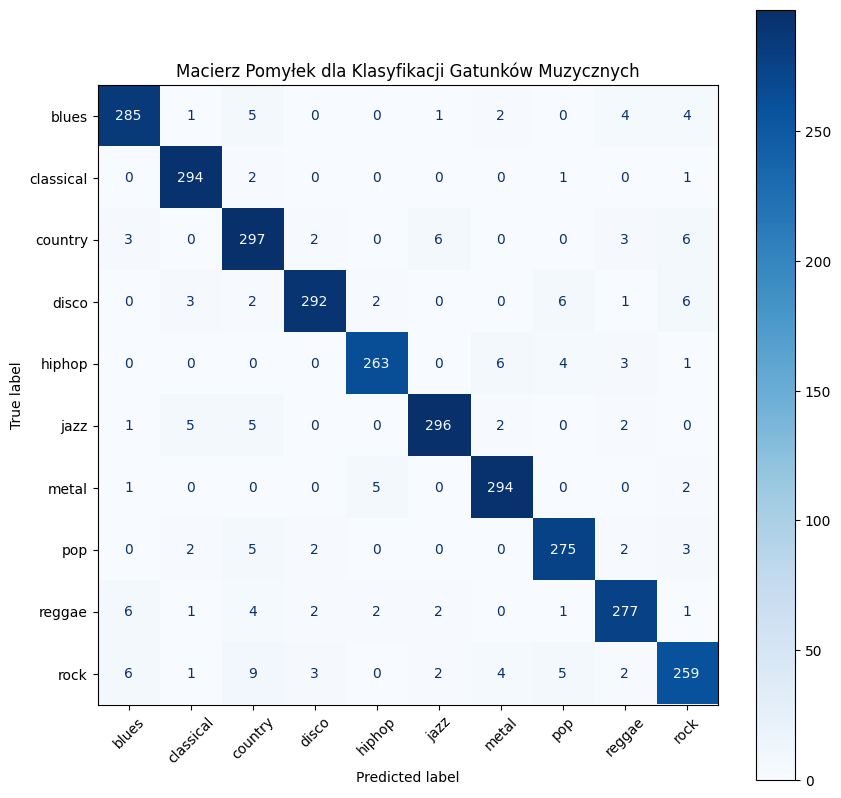

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
Y_pred_proba = second_model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10)) # Ustaw większy rozmiar
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Macierz Pomyłek dla Klasyfikacji Gatunków Muzycznych')
plt.xticks(rotation=45) # Obróć etykiety X, aby były czytelne
plt.show()